# Fashion MNIST Image Classifier with PyTorch

**Assignment 3 – Problem 2.** The *Building an Image Classifier with PyTorch* section of
Chapter 10 of *Hands-On Machine Learning with Scikit-Learn and PyTorch* (Aurélien Géron, 2025),
wrapped by Claude Code into a single self-contained notebook. It also plots the training accuracy.

**Contents**
1. Setup
2. Loading the dataset with TorchVision
3. Building the classifier
4. Training and evaluation helpers
5. Training the model
6. Plotting the training accuracy
7. Making predictions
8. Evaluating on the test set

## 1. Setup
Import the libraries, check versions, set plotting defaults and pick the fastest available device (CUDA GPU, Apple-silicon MPS, or CPU).

In [1]:
import sys
from packaging.version import Version

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchmetrics
import torchvision
import torchvision.transforms.v2 as T

assert sys.version_info >= (3, 10)
if Version(torch.__version__) < Version("2.6.0"):
    print(f"Note: PyTorch {torch.__version__} is older than the book's 2.6.0 "
          "(the code below works on any PyTorch 2.x)")

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("PyTorch", torch.__version__, "| torchvision", torchvision.__version__,
      "| device:", device)

/opt/anaconda3/lib/python3.12/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/lib/python3.12/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <367D4265-B20F-34BD-94EB-4F3EE47C385B> /opt/anaconda3/lib/python3.12/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/lib/python3.12/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/lib/python3.12/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Note: PyTorch 2.5.1 is older than the book's 2.6.0 (the code below works on any PyTorch 2.x)
PyTorch 2.5.1 | torchvision 0.20.1 | device: mps


## 2. Loading the dataset with TorchVision
Fashion MNIST has 70,000 grayscale 28×28 images of clothing in 10 classes. The transform turns each
image into a `float32` tensor scaled to [0, 1]. The 60,000 training images are split into 55,000 for
training and 5,000 for validation.

In [2]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

class_names = train_and_valid_data.classes
print(f"train: {len(train_data)}, valid: {len(valid_data)}, test: {len(test_data)}")
print("classes:", class_names)

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 65.5k/26.4M [00:00<01:19, 330kB/s]

  0%|          | 131k/26.4M [00:00<00:59, 442kB/s] 

  1%|          | 229k/26.4M [00:00<00:43, 608kB/s]

  2%|▏         | 426k/26.4M [00:00<00:25, 1.01MB/s]

...

100%|██████████| 4.42M/4.42M [00:01<00:00, 4.37MB/s]

Extracting datasets/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to datasets/FashionMNIST/raw



  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 6.48MB/s]

Extracting datasets/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to datasets/FashionMNIST/raw

train: 55000, valid: 5000, test: 10000
classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Each entry is an `(image, target)` tuple, and each image has the shape `[channels, rows, columns]`:

shape: torch.Size([1, 28, 28]) | dtype: torch.float32 | label: Ankle boot


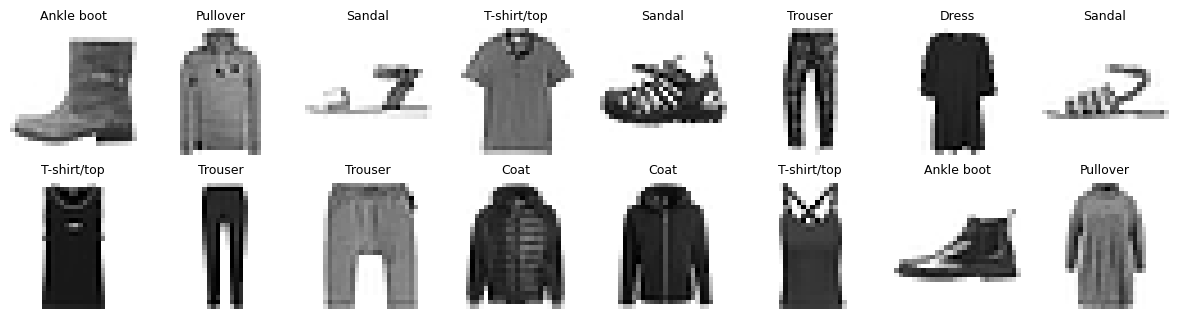

In [3]:
X_sample, y_sample = train_data[0]
print("shape:", X_sample.shape, "| dtype:", X_sample.dtype,
      "| label:", class_names[y_sample])

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, idx in zip(axes.flat, range(16)):
    image, label = train_data[idx]
    ax.imshow(image.squeeze(), cmap="binary")
    ax.set_title(class_names[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Building the classifier
A multilayer perceptron: flatten the 1×28×28 image into 784 inputs, then two hidden layers (300 and
100 ReLU units) and a 10-unit output layer that produces one logit per class.
`nn.CrossEntropyLoss` applies the softmax itself, so the model outputs raw logits.

In [4]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes)
        )

    def forward(self, X):
        return self.mlp(X)

torch.manual_seed(42)
model = ImageClassifier(n_inputs=1 * 28 * 28, n_hidden1=300, n_hidden2=100,
                        n_classes=10).to(device)
xentropy = nn.CrossEntropyLoss()

print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)
trainable parameters: 266610


## 4. Training and evaluation helpers
`evaluate_tm()` computes a `torchmetrics` metric over a data loader. `train2()` runs the training
loop and returns a `history` dict with the per-epoch training loss, training metric and validation
metric. Both are taken from earlier in Chapter 10.

In [5]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train2(model, optimizer, criterion, metric, train_loader, valid_loader,
           n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for X_batch, y_batch in train_loader:
            model.train()
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

## 5. Training the model
Train for 20 epochs with plain SGD (learning rate 0.1) and track multiclass accuracy.
The book discards the return value of `train2()`; here it is kept as `history` so it can be plotted.

In [6]:
n_epochs = 20
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
history = train2(model, optimizer, xentropy, accuracy, train_loader,
                 valid_loader, n_epochs)

Epoch 1/20, train loss: 0.6061, train metric: 0.7814, valid metric: 0.8402


Epoch 2/20, train loss: 0.4062, train metric: 0.8493, valid metric: 0.8452


Epoch 3/20, train loss: 0.3627, train metric: 0.8665, valid metric: 0.8522


Epoch 4/20, train loss: 0.3351, train metric: 0.8763, valid metric: 0.8626


Epoch 5/20, train loss: 0.3140, train metric: 0.8836, valid metric: 0.8758


...

Epoch 16/20, train loss: 0.2101, train metric: 0.9205, valid metric: 0.8848


Epoch 17/20, train loss: 0.2043, train metric: 0.9225, valid metric: 0.8830


Epoch 18/20, train loss: 0.1986, train metric: 0.9234, valid metric: 0.8876


Epoch 19/20, train loss: 0.1935, train metric: 0.9270, valid metric: 0.8764


Epoch 20/20, train loss: 0.1900, train metric: 0.9276, valid metric: 0.8796


## 6. Plotting the training accuracy
This section is new (it isn't in the book). The training accuracy is averaged over each epoch while
the weights are still changing, so it is plotted half an epoch earlier. Validation accuracy is shown
for comparison, with the training loss alongside.

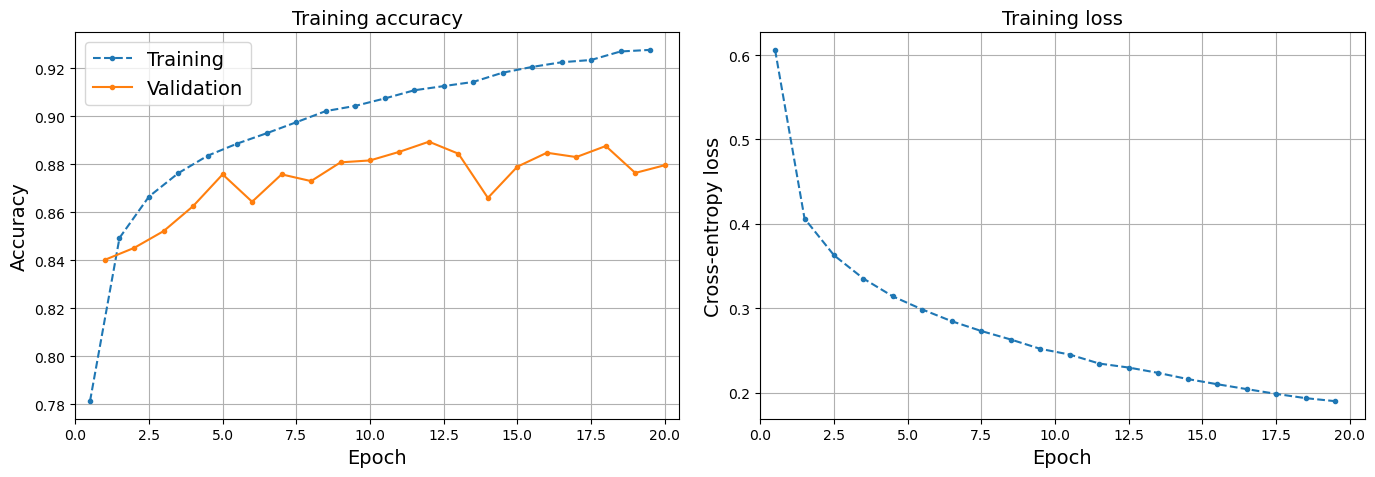

Final training accuracy:   0.9276
Final validation accuracy: 0.8796


In [7]:
epochs = np.arange(1, n_epochs + 1)
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))

ax_acc.plot(epochs - 0.5, history["train_metrics"], ".--", label="Training")
ax_acc.plot(epochs, history["valid_metrics"], ".-", label="Validation")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.set_title("Training accuracy")
ax_acc.set_xlim(0, n_epochs + 0.5)
ax_acc.grid()
ax_acc.legend()

ax_loss.plot(epochs - 0.5, history["train_losses"], ".--", color="C0")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Cross-entropy loss")
ax_loss.set_title("Training loss")
ax_loss.set_xlim(0, n_epochs + 0.5)
ax_loss.grid()

plt.tight_layout()
plt.show()

print(f"Final training accuracy:   {history['train_metrics'][-1]:.4f}")
print(f"Final validation accuracy: {history['valid_metrics'][-1]:.4f}")

## 7. Making predictions
Classify the first three validation images. The predicted class is the index of the largest logit,
and applying the softmax to the logits gives the estimated class probabilities.

In [8]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
y_pred = y_pred_logits.argmax(dim=1)

print("predicted:", [class_names[i] for i in y_pred])
print("actual:   ", [class_names[i] for i in y_new[:3]])

predicted: ['Sneaker', 'Coat', 'Pullover']
actual:    ['Sneaker', 'Coat', 'Pullover']


In [9]:
y_proba = F.softmax(y_pred_logits, dim=1).cpu()
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8540, 0.0000,
         0.1450],
        [0.0000, 0.0000, 0.0050, 0.0000, 0.9940, 0.0000, 0.0010, 0.0000, 0.0000,
         0.0000],
        [0.0020, 0.0000, 0.6470, 0.0000, 0.1150, 0.0000, 0.2360, 0.0000, 0.0000,
         0.0000]])

The top 4 classes for each image and their probabilities (renormalized over those 4 classes):

In [10]:
y_top4_values, y_top4_indices = torch.topk(y_pred_logits, k=4, dim=1)
y_top4_probas = F.softmax(y_top4_values, dim=1).cpu()
for i in range(3):
    ranked = ", ".join(f"{class_names[c]} {p:.3f}"
                       for c, p in zip(y_top4_indices[i].tolist(),
                                       y_top4_probas[i].tolist()))
    print(f"image {i}: {ranked}")

image 0: Sneaker 0.854, Ankle boot 0.145, Sandal 0.000, Bag 0.000
image 1: Coat 0.994, Pullover 0.005, Shirt 0.001, T-shirt/top 0.000
image 2: Pullover 0.647, Shirt 0.236, Coat 0.115, T-shirt/top 0.002


## 8. Evaluating on the test set
Finally, measure how well the model generalizes to the 10,000 held-out test images.

In [11]:
test_accuracy = evaluate_tm(model, test_loader, accuracy).item()
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.8832
